In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(f"Размерность данных: {X.shape}, {type(X)=}")
print(f"Целевая переменная: {y[:5]}, {type(y)=}")  # Первые 5 значений цены
print(f"\nПризнаки: {housing.feature_names}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Размерность данных: (20640, 8), type(X)=<class 'pandas.core.frame.DataFrame'>
Целевая переменная: [4.526 3.585 3.521 3.413 3.422], type(y)=<class 'numpy.ndarray'>

Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Обучающая выборка: 16512 samples
Тестовая выборка: 4128 samples


In [3]:
# Создание и обучение модели LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,        # Количество деревьев
    learning_rate=0.1,       # Скорость обучения
    max_depth=5,             # Максимальная глубина деревьев
    random_state=42,
    verbosity=-1             # Отключение выводов
)

# Обучение модели
lgb_model.fit(X_train, y_train)

# Прогнозирование
y_pred = lgb_model.predict(X_test)


LightGBM Результаты:
Среднеквадратичная ошибка (MSE): 0.2385
Корень из MSE (RMSE): 0.4884
Средняя абсолютная ошибка (MAE): 0.3269
Коэффициент детерминации (R²): 0.8180


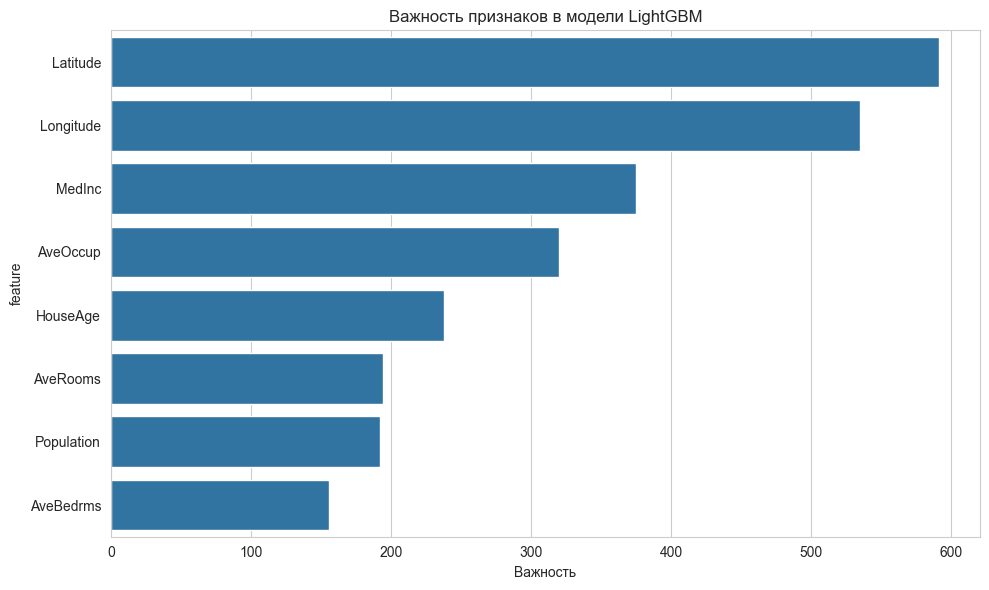

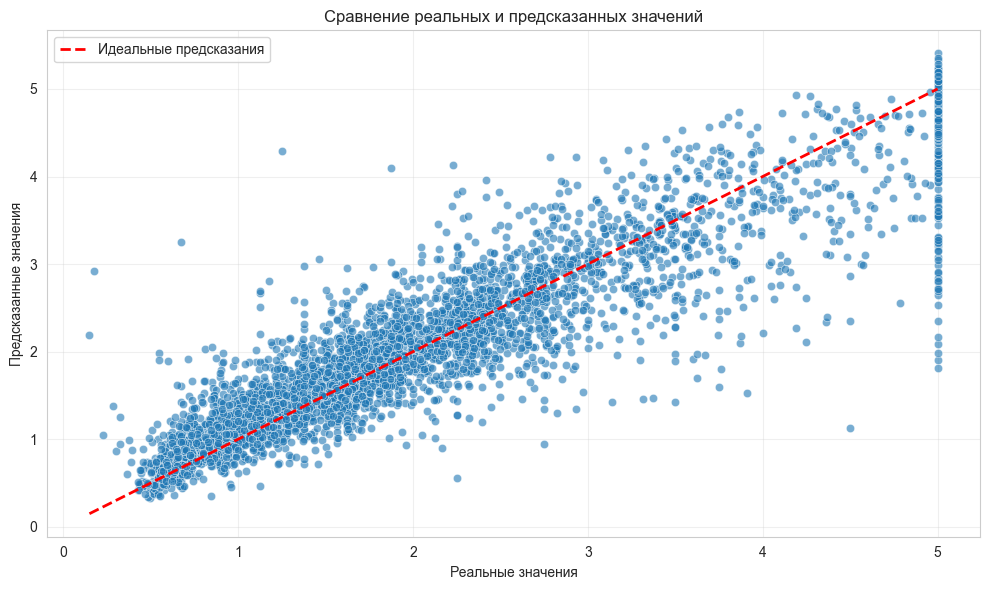

In [4]:
# Оценка качества модели
def evaluate_model(y_true, y_pred, model_name):
    """Функция для оценки модели регрессии"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Результаты:")
    print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
    print(f"Корень из MSE (RMSE): {rmse:.4f}")
    print(f"Средняя абсолютная ошибка (MAE): {mae:.4f}")
    print(f"Коэффициент детерминации (R²): {r2:.4f}")

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

results = evaluate_model(y_test, y_pred, "LightGBM")

# Визуализация важности признаков
feature_importance = pd.DataFrame({
    'feature': housing.feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Важность признаков в модели LightGBM')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Визуализация предсказаний vs реальные значения
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Идеальные предсказания')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Сравнение реальных и предсказанных значений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Оптимизация гиперпараметров с помощью GridSearchCV**

In [6]:
# Определяем сетку параметров для поиска
param_grid = {
    'n_estimators': [100, 200, 300], # Количество деревьев
    'learning_rate': [0.01, 0.1, 0.2], # Скорость обучения
    'max_depth': [3, 5, 7, 9, 10, 12], # Максимальная глубина деревьев
    'num_leaves': [31, 50, 100], # Количество листьев в дереве
    'subsample': [0.5, 0.8, 1.0] # Доля выборки для обучения каждого дерева
}

# Создаем и обучаем модель с поиском по сетке
grid_search = GridSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42, verbosity=-1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

In [7]:
# Для ускорения демонстрации используем подвыборку
# grid_search.fit(X_train[:1000], y_train[:1000])
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший MSE: {-grid_search.best_score_:.4f}")

# Используем лучшую модель
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_results = evaluate_model(y_test, y_pred_best, "Оптимизированный LightGBM")

# Сравнение результатов
print("\n=== Сравнение моделей ===")
print(f"Улучшение RMSE: {results['RMSE'] - (-grid_search.best_score_)**0.5:.4f}")
print(f"Улучшение R²: {best_results['R2'] - results['R2']:.4f}")

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.5}
Лучший MSE: 0.2122

Оптимизированный LightGBM Результаты:
Среднеквадратичная ошибка (MSE): 0.1952
Корень из MSE (RMSE): 0.4418
Средняя абсолютная ошибка (MAE): 0.2900
Коэффициент детерминации (R²): 0.8510

=== Сравнение моделей ===
Улучшение RMSE: 0.0277
Улучшение R²: 0.0330


"\nЛучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.8}\nЛучший MSE: 0.2177\n"

**Пример использования ранней остановки**

In [8]:
# Создаем датасеты для LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Параметры модели
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'max_depth': 5,
    'num_leaves': 31,
    'verbosity': -1
}

# Обучение с ранней остановкой
model_early_stop = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)  # Выводим логи каждые 50 итераций
    ]
)

# Предсказание на тестовых данных
y_pred_early = model_early_stop.predict(X_test)
early_results = evaluate_model(y_test, y_pred_early, "LightGBM с ранней остановкой")

print(f"\nКоличество использованных деревьев: {model_early_stop.best_iteration}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 0.521769
[100]	valid_0's rmse: 0.488363
[150]	valid_0's rmse: 0.472769
[200]	valid_0's rmse: 0.465397
[250]	valid_0's rmse: 0.457128
[300]	valid_0's rmse: 0.452447
[350]	valid_0's rmse: 0.448944
[400]	valid_0's rmse: 0.446584
[450]	valid_0's rmse: 0.444383
[500]	valid_0's rmse: 0.442529
[550]	valid_0's rmse: 0.440798
[600]	valid_0's rmse: 0.440588
[650]	valid_0's rmse: 0.439613
[700]	valid_0's rmse: 0.439695
[750]	valid_0's rmse: 0.439018
[800]	valid_0's rmse: 0.43769
[850]	valid_0's rmse: 0.437262
[900]	valid_0's rmse: 0.436746
[950]	valid_0's rmse: 0.436723
[1000]	valid_0's rmse: 0.436574
Did not meet early stopping. Best iteration is:
[981]	valid_0's rmse: 0.436351

LightGBM с ранней остановкой Результаты:
Среднеквадратичная ошибка (MSE): 0.1904
Корень из MSE (RMSE): 0.4364
Средняя абсолютная ошибка (MAE): 0.2849
Коэффициент детерминации (R²): 0.8547

Количество использованных деревьев: 981
